# Metodología de preprocesamiento

1. Visualizar al atributo a preprocesar 
2. Inferir la estrategia de preprocesamiento. 
3. Justificar la estrategia de preprocesamiento desde referentes teóricos. 

# Preprocesameinto de la variable objetivo 

Aplicar una transformación logarítmica a tu variable `casos_dengue` no solo es adecuado, sino que en este caso es **altamente recomendable**.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [3]:
path_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\1_datos_semana_epi_meteo\datos_semanal_meteo_epi.xlsx"
path_marco = r"C:\Users\marco\Documentos\investigacion\arima\05_preprocesado\2_datos\1_raw\meteo_epi_rezagos.xlsx"
df_meteo_epi_rezagos = pd.read_excel(path_marco)
# hacer que fecha sea el indice y sea de tipo datetime
df_meteo_epi_rezagos['fecha'] = pd.to_datetime(df_meteo_epi_rezagos['fecha']) # convertir en tipo datetime
df_meteo_epi_rezagos.set_index('fecha', inplace=True)  # hacer que fecha sea el indice

df_meteo_epi_rezagos.head()

,año,semana_epi,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,...,soi_lag_8,soi_lag_9,soi_lag_10,soi_lag_11,soi_lag_12,sst_lag_8,sst_lag_9,sst_lag_10,sst_lag_11,sst_lag_12
fecha,,,,,,,,,,,,,,,,,,,,,
2021-01-03,2021,1,28.254286,34.200000,23.832857,16.367143,70.774286,7.73,1,0.124286,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-10,2021,2,28.638571,34.910000,24.195714,17.318571,73.095714,19.18,5,0.111429,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-17,2021,3,29.552857,36.372857,24.090000,16.122857,65.328571,0.80,0,0.122857,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-24,2021,4,29.208571,35.978571,24.200000,16.564286,68.205714,12.81,5,0.122857,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-31,2021,5,29.421429,35.882857,24.684286,17.311429,69.797143,18.06,3,0.117143,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_meteo_epi_rezagos.columns 

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       ...
       'soi_lag_8', 'soi_lag_9', 'soi_lag_10', 'soi_lag_11', 'soi_lag_12',
       'sst_lag_8', 'sst_lag_9', 'sst_lag_10', 'sst_lag_11', 'sst_lag_12'],
      dtype='str', length=114)

In [5]:
# Lista de columnas que deseas excluir
columnas_a_excluir = ['casos_dengue', 'semana_epi', 'año']

# Comprensión de listas para filtrar las columnas
variables_a_estandarizar = [col for col in df_meteo_epi_rezagos.columns if col not in columnas_a_excluir]

# Prompt  

Ahora, dame el código para estalar las columnas de este dataframe correspondientes a las variables a estandarizar y luego definir el dataframe `df_meteo_epi_rezagos_estandarizado` con las variables entandarizadas e incluir las variables no estandarizadas con StandardScaler de sklearn

In [ ]:
# Guardar solo las datos procesados sin originales ni lambdas
df_solo_procesados = df_procesados[variables_a_estandarizar].copy()
df_solo_procesados.to_excel(f"{ubicacion_datos_consolidados_janis}/df_solo_procesados.xlsx", index=False)
print("Archivo df_solo_procesados.xlsx guardado con solo las variables estandarizadas (sin índice ni lambdas)")


✅ Archivo df_solo_procesados.xlsx guardado con solo las variables estandarizadas (sin índice ni lambdas)


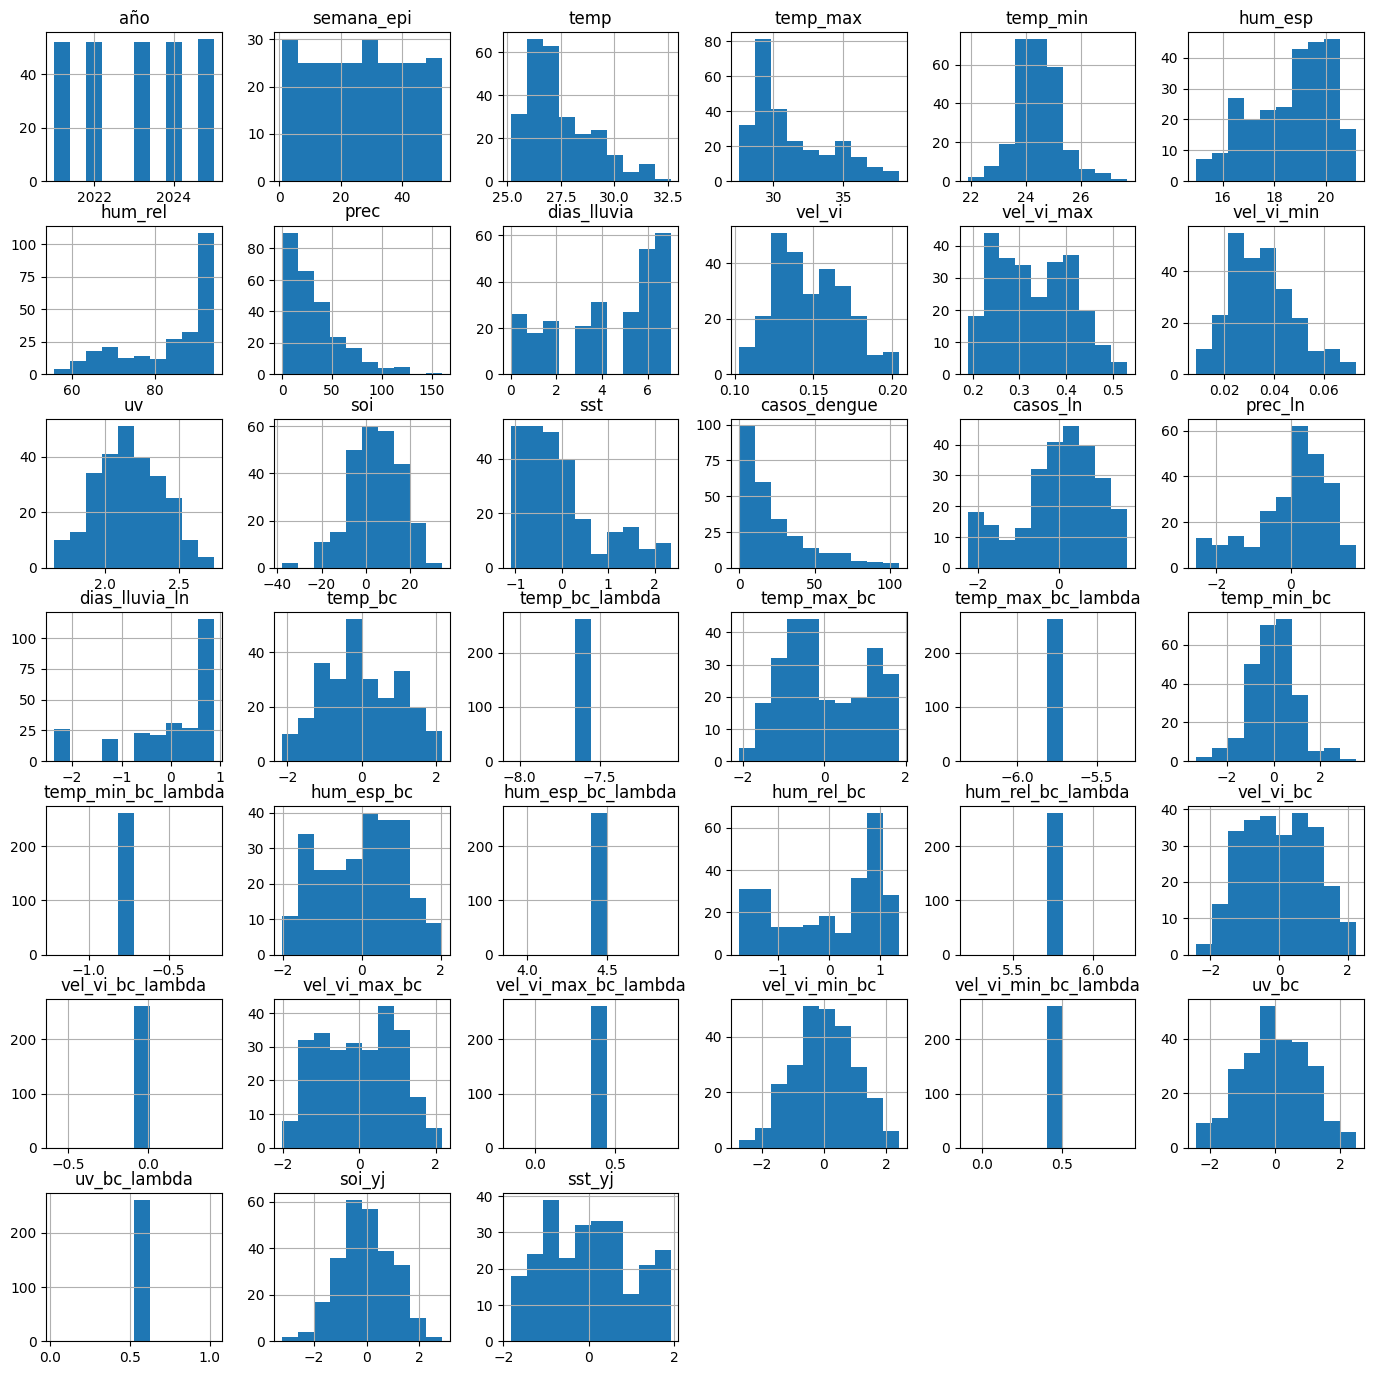

In [ ]:
# Histogramas de todas las variables transformadas y estandarizadas sin las columnas de lambda
df_procesados.hist(figsize=(17,17))
plt.savefig(f"{ubicacion_imagenes_janis}/1.histogramas_procesados_sin_rezagos.png")
plt.show() 

## Prueba de normalidad

In [16]:
from scipy.stats import shapiro

# Seleccionar solo las columnas numéricas
numericas = df_procesados.select_dtypes(include=["float64", "int64"]) # esto elimina la fecha de lso atributos a determinar correlacion

#Eliminar año y semana_epi
numericas = numericas.drop(columns=['año', 'semana_epi', 'temp_bc_lambda', 'temp_max_bc_lambda', 'temp_min_bc_lambda', 'hum_esp_bc_lambda', 'hum_rel_bc_lambda', 'vel_vi_bc_lambda', 'vel_vi_max_bc_lambda', 'vel_vi_min_bc_lambda', 'uv_bc_lambda'])

# Aplicar Shapiro-Wilk a cada variable
resultados_normalidad = {}
for col in numericas.columns:
    stat, p = shapiro(numericas[col].dropna())
    resultados_normalidad[col] = {"Estadístico W": stat, "Valor p": p}

# Mostrar resultados
df_normalidad = pd.DataFrame(resultados_normalidad).T
df_normalidad["Normal (p>0.05)"] = df_normalidad["Valor p"] > 0.05
df_normalidad

,Estadístico W,Valor p,Normal (p>0.05)
temp,0.917537,8.004622e-11,False
temp_max,0.883120,2.825387e-13,False
temp_min,0.980537,1.226305e-03,False
hum_esp,0.948490,5.846115e-08,False
hum_rel,0.830594,3.401543e-16,False
prec,0.890732,8.840685e-13,False
dias_lluvia,0.880142,1.833430e-13,False
vel_vi,0.977046,3.204057e-04,False
vel_vi_max,0.964436,4.612705e-06,False
vel_vi_min,0.975928,2.120517e-04,False


## Se aplicará VIF para detectar multicolinealidad entre las variables transformadas y estandarizadas, y así decidir cuáles incluir en el modelo ARIMA con rezagos.

In [19]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ============================
# VIF DE TODAS LAS VARIABLES
# ============================

# Seleccionar solo columnas numéricas
X = df_procesados.select_dtypes(include=[np.number]).copy()

# Eliminar columnas que tengan un solo valor (constantes) → causan VIF infinito
X = X.loc[:, X.nunique() > 1]

# Eliminar filas con NaN
X = X.dropna()

print(f"Dimensiones del dataframe para VIF: {X.shape}")

# Agregar constante
X_const = add_constant(X)

# Calcular VIF
vif_data = pd.DataFrame()
vif_data['Variable'] = X_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

# Ordenar de mayor a menor VIF
vif_data = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)

# Mostrar resultados
print("🔍 MULTICOLINEALIDAD - VIF DE TODAS LAS VARIABLES")
print("="*70)
print(vif_data.round(2))

# Resumen por niveles de problema
print("\n" + "="*70)
print("RESUMEN DE PROBLEMAS:")
print(vif_data[vif_data['VIF'] > 10][['Variable', 'VIF']])

Dimensiones del dataframe para VIF: (261, 30)
🔍 MULTICOLINEALIDAD - VIF DE TODAS LAS VARIABLES
          Variable          VIF
0            const  11531673.68
1          hum_rel      6060.08
2             temp      2722.72
3          hum_esp      2024.75
4         temp_min      1928.58
5      temp_min_bc      1798.22
6            uv_bc      1419.00
7               uv      1407.54
8         temp_max       696.54
9    vel_vi_max_bc       536.86
10      vel_vi_max       491.14
11      hum_rel_bc       465.52
12      hum_esp_bc       351.75
13       vel_vi_bc       340.63
14         temp_bc       308.53
15          vel_vi       305.50
16     temp_max_bc       271.67
17             soi       203.44
18          soi_yj       203.24
19      vel_vi_min        68.24
20   vel_vi_min_bc        64.35
21  dias_lluvia_ln        40.51
22     dias_lluvia        26.54
23          sst_yj        22.97
24         prec_ln        22.68
25             sst        21.49
26        casos_ln         9.78
27       

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Variables seleccionadas (ajusta según lo que quieras probar)
variables_seleccionadas = [
    'hum_esp_bc', 
    'temp_max_bc',
    'dias_lluvia_ln',
    'Vel_vi_bc',
    'vel_vi_max_bc',
    'sst_yj'          # opcional
]

X = df_procesados[variables_seleccionadas].copy()
X = X.dropna()

X = add_constant(X)

vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data.round(2))

## A continuacion, se harán los rezagos según la recomendación dada por la correlación cruzada Y VIF, para cada variable exógena. Se crearán nuevas columnas con el formato "variable_lagX" donde X es el número de semanas de rezago.

In [10]:
print(df_procesados.index.name)

fecha


### Base de datos con variables que tuvieron significancia del 95%, con los rezagos más importantes que se encontraron en el análisis de correlación cruzada

In [13]:
# =========================================================
# 1. CREAR DATAFRAME SOLO CON VARIABLES NECESARIAS
# =========================================================

datos_procesados_rezagos = df_sin_lambda[[
    'año',
    'semana_epi',
    'casos_ln',
    'hum_esp_bc',
    'hum_rel_bc',
    'vel_vi_max_bc',
    'temp_max_bc',
    'vel_vi_bc',
    'dias_lluvia_ln',
    'prec_ln',
    'temp_bc',
    'sst_yj'
]].copy()

# =========================================================
# 2. ASEGURAR QUE LA FECHA ESTÉ COMO ÍNDICE
# =========================================================

if not pd.api.types.is_datetime64_any_dtype(datos_procesados_rezagos.index):
    datos_procesados_rezagos.index = pd.to_datetime(
        datos_procesados_rezagos.index
    )

# Convertir índice a columna llamada fecha
datos_procesados_rezagos.reset_index(inplace=True)

# Renombrar columna índice
datos_procesados_rezagos.rename(
    columns={'index': 'fecha'},
    inplace=True
)

print("✅ Columnas fecha, año y semana_epi agregadas")


# =========================================================
# 3. CREACIÓN DE REZAGOS (SELECCIÓN DIRIGIDA)
# =========================================================

# Diccionario con rezagos seleccionados
lags_dict = {
    'hum_esp_bc': [1, 3, 6],
    'prec_ln': [1, 4, 5, 8],
    'temp_max_bc': [1, 3, 5, 7],
    'vel_vi_max_bc': [2, 3, 5],
    'sst_yj': [8, 10, 12, 16],
}

# Crear rezagos
for var, lags in lags_dict.items():
    for lag in lags:
        datos_procesados_rezagos[f"{var}_lag_{lag}"] = (
            datos_procesados_rezagos[var].shift(lag)
        )



print("✅ Rezagos creados correctamente")


# =========================================================
# 4. ELIMINAR FILAS CON NaN
# =========================================================

print("\nDimensiones antes de eliminar NaN:")
print(datos_procesados_rezagos.shape)

datos_procesados_rezagos = datos_procesados_rezagos.dropna()

print("\nDimensiones después de eliminar NaN:")
print(datos_procesados_rezagos.shape)

print("\n✅ Filas vacías eliminadas correctamente")


# =========================================================
# 5. GUARDAR ARCHIVO FINAL
# =========================================================

datos_procesados_rezagos.to_excel(
    f"{ubicacion_datos_consolidados_janis}/datos_corr_9_variables_rezagos_relevantes.xlsx",
    index=False,
    sheet_name='datos_modelo_rezagos'
)

print("\n✅ Archivo guardado correctamente:")
print("→ datos_modelo_rezagos.xlsx")

✅ Columnas fecha, año y semana_epi agregadas
✅ Rezagos creados correctamente

Dimensiones antes de eliminar NaN:
(261, 31)

Dimensiones después de eliminar NaN:
(245, 31)

✅ Filas vacías eliminadas correctamente

✅ Archivo guardado correctamente:
→ datos_modelo_rezagos.xlsx


### Base de datos con variables que tuvieron el rezago más significativo (VIF < 10) y significancia del 95%

In [ ]:
# =========================================================
# 1. SELECCIONAR VARIABLES FINALES
# =========================================================

variables_finales = [
    'fecha',
    'año',
    'semana_epi',
    'casos_ln',

    'hum_esp_bc_lag_3',
    'hum_rel_bc_lag_1',
    'vel_vi_max_bc_lag_3',
    'vel_vi_bc_lag_4',
    'dias_lluvia_ln_lag_5',
    'prec_ln_lag_8',
    'temp_max_bc_lag_1',
    'temp_bc_lag_1',
    'sst_yj_lag_16'
]

# Selección segura de variables (omitir columnas faltantes y avisar)
existing_vars = [v for v in variables_finales if v in datos_procesados_rezagos.columns]
missing_vars = [v for v in variables_finales if v not in datos_procesados_rezagos.columns]

if missing_vars:
    print("⚠️ Columnas solicitadas no encontradas en datos_procesados_rezagos (se omiten):")
    print(missing_vars)

# Asegurar columnas obligatorias
required = ['fecha', 'año', 'semana_epi', 'casos_ln']
for r in required:
    if r not in datos_procesados_rezagos.columns:
        raise KeyError(f"Columna obligatoria faltante en datos_procesados_rezagos: {r}")
    if r not in existing_vars:
        existing_vars.insert(0, r)

df_modelo = datos_procesados_rezagos[existing_vars].copy()

print("✅ DataFrame reducido creado")
print(df_modelo.shape)


# =========================================================
# 2. PREPARAR VARIABLES PARA VIF
# =========================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Variables exógenas (sin fecha ni variable respuesta)
X = df_modelo.drop(
    columns=['fecha', 'año', 'semana_epi', 'casos_ln']
)

# =========================================================
# 3. CALCULAR VIF
# =========================================================

vif_df = pd.DataFrame()

vif_df['Variable'] = X.columns

vif_df['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Ordenar de mayor a menor
vif_df = vif_df.sort_values(
    by='VIF',
    ascending=False
)

print("\n✅ VIF calculado correctamente")
print(vif_df)

KeyError: "['hum_rel_bc_lag_1', 'vel_vi_bc_lag_4', 'dias_lluvia_ln_lag_5', 'temp_bc_lag_1'] not in index"

In [ ]:
X_reducido = X.drop(columns=['hum_rel_bc_lag_1', 'prec_ln_lag_5', 'temp_bc_lag_1'])

vif_df2 = pd.DataFrame()

vif_df2['Variable'] = X_reducido.columns

vif_df2['VIF'] = [
    variance_inflation_factor(X_reducido.values, i)
    for i in range(X_reducido.shape[1])
]

vif_df2 = vif_df2.sort_values(
    by='VIF',
    ascending=False
)

print(vif_df2)

               Variable       VIF
4     temp_max_bc_lag_1  3.132389
0      hum_esp_bc_lag_1  2.733423
1   vel_vi_max_bc_lag_1  2.218406
3  dias_lluvia_ln_lag_5  2.051773
2       vel_vi_bc_lag_4  1.978976
5         sst_yj_lag_10  1.406182


In [ ]:
# =========================================================
# 1. SELECCIONAR VARIABLES FINALES DEL MODELO
# =========================================================

variables_finales = [
    'fecha',
    'año',
    'semana_epi',
    'casos_ln',

    'hum_esp_bc_lag_1',
    'vel_vi_max_bc_lag_1',
    'vel_vi_bc_lag_4',
    'dias_lluvia_ln_lag_5',
    'temp_max_bc_lag_1',
    'sst_yj_lag_10'
]

# Crear dataframe final
datos_corr_rezago_relevante = datos_procesados_rezagos[
    variables_finales
].copy()

print("✅ DataFrame final creado correctamente")
print(datos_corr_rezago_relevante.shape)

print("\nColumnas del dataframe:")
print(datos_corr_rezago_relevante.columns)


# =========================================================
# 2. GUARDAR DATAFRAME FINAL
# =========================================================

datos_corr_rezago_relevante.to_excel(
    f"{ubicacion_datos_consolidados_janis}/datos_corr_rezago_relevante.xlsx",
    index=False,
    sheet_name='datos_corr_rezago_relevante'
)

print("\n✅ Archivo guardado correctamente:")
print("→ datos_modelo_corr.xlsx")

✅ DataFrame final creado correctamente
(249, 10)

Columnas del dataframe:
Index(['fecha', 'año', 'semana_epi', 'casos_ln', 'hum_esp_bc_lag_1',
       'vel_vi_max_bc_lag_1', 'vel_vi_bc_lag_4', 'dias_lluvia_ln_lag_5',
       'temp_max_bc_lag_1', 'sst_yj_lag_10'],
      dtype='object')

✅ Archivo guardado correctamente:
→ datos_modelo_corr.xlsx


### Base de datos con las 13 variables y cada una de ellas con 12 rezagos

### Utilizando los promedios de los rezagos


Aquí tienes el análisis detallado basado en el histograma y los modelos de series temporales que planeas usar:



### 1. ¿Por qué es adecuado aplicar el logaritmo?

El histograma muestra una **asimetría positiva severa** (sesgo a la derecha o *right-skewed*). La gran mayoría de los datos se concentran en valores bajos (cercanos a 0-20), pero tienes una "cola" larga que llega hasta más de 100.



* **Estabilización de la varianza:** En datos de epidemiología (como el dengue), la varianza suele crecer proporcionalmente a la media (a más casos, más fluctuación). El logaritmo ayuda a que la varianza sea constante (**homocedasticidad**), un requisito clave para modelos lineales como ARIMA.


* **Normalización:** Los modelos ARIMA/SARIMA asumen que los residuos del modelo siguen una distribución normal. Al aplicar logaritmo, "comprimes" los valores altos y "expandes" los bajos, haciendo que la distribución se acerque más a una campana de Gauss.


* **Linealización de relaciones:** El dengue suele crecer de forma exponencial durante brotes. El logaritmo convierte ese crecimiento exponencial en uno lineal, que es mucho más fácil de capturar para un modelo ARIMAX.




### 2. Justificación: ¿Es aplicable no hacer preprocesamiento?

Si decides **no** aplicar preprocesamiento (dejar la variable en su escala original), te enfrentarás a varios problemas técnicos que probablemente degraden el rendimiento de tus modelos:

* **Sensibilidad a valores extremos:** Sin preprocesamiento, los picos de casos (outliers visuales en la cola derecha) tendrán un peso desproporcionado en el cálculo del error (MSE). El modelo intentará "perseguir" esos picos y perderá precisión en los periodos normales.
* **Predicciones negativas:** Si no transformas los datos y el modelo detecta una tendencia bajista fuerte cerca de cero, ARIMA podría predecir valores negativos de casos, lo cual es físicamente imposible. Al usar $\log(y)$, la predicción revertida $\exp(\hat{y})$ siempre será positiva.
* **Falta de convergencia:** En SARIMAX, si la estacionalidad es **multiplicativa** (el tamaño de los picos estacionales varía con el nivel de la serie), los modelos ARIMA (que son aditivos por naturaleza) fallarán estrepitosamente a menos que uses el logaritmo para convertir esa relación en aditiva.

---



### 3. Consideraciones para ARIMA, ARIMAX y SARIMAX

Al trabajar con estos modelos específicos, ten en cuenta lo siguiente:

1.  **Manejo de ceros:** Si tienes semanas con **0 casos**, el $\log(0)$ es indefinido. Debes aplicar una transformación $\log(y + 1)$.
2.  **Diferenciación ($d, D$):** Es muy probable que después del logaritmo sigas necesitando diferenciar la serie para hacerla estacionaria. El logaritmo estabiliza la varianza, pero la diferenciación estabiliza la media.
3.  **Variables Exógenas (ARIMAX):** Si usas variables como temperatura o precipitación, asegúrate de evaluar si estas también necesitan transformación. La relación entre "Temperatura" y "$\log(\text{Casos})$" suele ser mucho más robusta estadísticamente.
4.  **Interpretación:** Recuerda que al terminar, deberás aplicar la función inversa ($\exp$) a tus predicciones para volver a la escala original de "número de personas".

**En conclusión:** No preprocesar esta variable sería un error metodológico dado el sesgo visible. La transformación logarítmica es el estándar de oro para este tipo de distribuciones en modelos de series de tiempo.

# Referentes que justifican este preprocesamiento  

Para sustentar tu decisión académica o investigativa, puedes apoyarte en estos 5 referentes y pilares técnicos que validan la transformación logarítmica en modelos de conteo epidemiológico y series temporales:

### 1. Box & Cox (La Transformación de Box-Cox)
George Box y David Cox son los referentes primordiales. Su metodología demuestra que para variables que no son normales y tienen varianza no constante, una transformación de potencia (donde el logaritmo es el caso más común) es esencial para que los modelos lineales sean válidos.
* **Argumento:** Sin esta transformación, violas los supuestos de **homocedasticidad** necesarios para que los estimadores de tu ARIMA sean eficientes.

### 2. Rob J. Hyndman (*Forecasting: Principles and Practice*)
Es probablemente el autor más influyente hoy en día en series de tiempo. En su libro de referencia, explica que si la variación estacional de una serie parece crecer con el nivel de la serie (como ocurre en los brotes de dengue), se debe usar una transformación logarítmica para convertir la **estacionalidad multiplicativa en aditiva**.
* **Argumento:** Los modelos SARIMA estándar son aditivos; el logaritmo es la herramienta para que el modelo "entienda" crecimientos exponenciales.



### 3. Organización Panamericana de la Salud (OPS) - Guías de Vigilancia
En sus manuales técnicos para el análisis de brotes, la OPS recomienda frecuentemente el uso de tasas o transformaciones logarítmicas al graficar y modelar curvas epidémicas para estabilizar la visualización de la tendencia frente a los picos súbitos de casos.
* **Argumento:** El logaritmo ayuda a comparar la tasa de crecimiento entre diferentes periodos, independientemente de la magnitud absoluta del brote.

### 4. Robert Shumway y David Stoffer (*Time Series Analysis and Its Applications*)
Referentes académicos clásicos. Explican que para datos de conteo (como el número de enfermos), la distribución suele seguir una **Poisson** o una **Binomial Negativa**, donde la varianza aumenta con la media.
* **Argumento:** El logaritmo actúa como una "función de enlace" que permite tratar estos datos de conteo dentro del marco de los modelos gaussianos (como ARIMA).

### 5. Estudios de Caso en *The Lancet* o *Nature* (Modelado de Dengue)
Si buscas literatura específica, autores como **Moritz Kraemer** o **Simon Hay**, expertos en mapeo de enfermedades infecciosas, suelen preprocesar los datos de incidencia mediante $\log(n + 1)$ para manejar la sobredispersión de los datos de dengue en climas tropicales.
* **Argumento:** En el mundo real, los datos de dengue tienen muchos "ceros" y "picos". El preprocesamiento no es opcional, es el estándar para evitar que el ruido de los picos domine la señal del modelo.

---

### Resumen para tu investigación:
| Referente | Concepto Clave | Aplicación en tu caso |
| :--- | :--- | :--- |
| **Box-Cox** | Estabilización de varianza | Corregir el sesgo que ves en tu histograma. |
| **Hyndman** | Estacionalidad aditiva | Hacer que SARIMAX funcione correctamente. |
| **OPS** | Curvas Epidémicas | Normalizar la visualización de brotes. |
| **Shumway & Stoffer** | Linealización | Permitir que ARIMAX use regresores externos de forma lineal. |
| **Kraemer / Hay** | $\log(n+1)$ | Manejo de semanas con cero casos y alta dispersión. |

¿Necesitas ayuda con la implementación del código para realizar la transformación inversa tras obtener las predicciones?

# Preprocesamiento de casos_dengue en Python  


In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df_pre= pd.read_excel(r"C:\Users\usuario1\Documents\GitHub\arima\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\03_fusionados_y_limpieza_datos\df_final_fusionado.xlsx")
df_pre.head()